In [1]:
import re
import json
import pandas as pd
import numpy as np
from datetime import datetime
import pycountry
from IPython.display import display, Markdown
from numpyro import distributions as dist
import yaml as yml
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
import git
import yaml as yml

from emu_renewal.constants import BASE_PATH, OUTPUTS_PATH
from emu_renewal.selection import get_mob_avail_countries, gather_who_data, find_absent_inds, \
    find_neg_inds, find_outliers, find_nans_repeats
from emu_renewal.inputs import get_worldbank_national_pop, get_income_group, get_fb_visited_mobility, \
    get_fb_singletile_mobility, process_raw_google_mobility, get_google_mobility, get_country_pop, \
    get_undesa_national_pop, get_country_vacc_data, get_world_shp
from emu_renewal.outputs import get_table_df_from_priors_dict, add_bool_row_to_table, add_mob_avail_to_world
from emu_renewal.document import get_func_blurb
from emu_renewal.indicators import get_deaths_target, get_cases_target, filter_seroprev, get_owid_hosps, \
    get_all_seroprev, get_seroprev_pooled_totals, get_var_target, extract_specific_var, get_country_vars, \
    get_alpha_info, get_delta_info, get_specific_var_props, \
    get_ba2_info, get_ba5_info
from emu_renewal.run import find_run_start_time, find_run_end_time, get_hosp_target, get_seroprev_target, \
    get_mobility_provider, run_calibration
from emu_renewal.geospatial import FacebookMobilityBuilder
from emu_renewal.renew import MultiStrainModel
from emu_renewal.distributions import GammaDens
from emu_renewal.process import _get_cos_curve_at_x
from emu_renewal.mobility import NoMobilityProvider, WeightedExpMobilityProvider, SingleSeriesExpMobilityProvider
from emu_renewal.calibration import custom_init, StandardCalib
from emu_renewal.priors import get_standard_priors
from emu_renewal.plotting import plot_beta_priors, plot_duration_params, plot_inclusion

plt.style.use("default")
set_matplotlib_formats("svg")

{{< pagebreak >}}

# Documentation

In [2]:
commit = git.Repo(search_parent_directories=True).head
txt = (
    "The following document was documented algorithmically "
    "from the code used in the analysis.\n"
)
txt += f"This version was produced from commit {commit.object.hexsha}. \n\n"
txt += "# Analysis methods \n\n"
txt += "## Modelled population size \n\n"
txt += get_func_blurb(get_country_pop)
txt += get_func_blurb(get_worldbank_national_pop)
txt += get_func_blurb(get_undesa_national_pop)
txt += "\n\n## Analysis period\n"
analysis_period_rationale = (
    "For all countries, we aimed to place our analysis period "
    "during a time period for which the variation in transmission rate "
    "was likely to be predominantly attributable to changes in mobility, "
    "although we developed an approach (described below) to address "
    "the consideration that the emergence of new SARS-CoV-2 variants "
    "likely contributed substantially. "
    "Therefore, we aimed to select time periods during which "
    "the roll-out of vaccination programs would have contributed "
    "less to variations in transmission rate.\n\n"
    "For all countries other than Oceania and Singapore, we addressed this "
    "by limiting our analysis period to the time period prior to "
    "vaccination reaching levels that may have had a significant "
    "population-level effect."
)
txt += analysis_period_rationale
txt += get_func_blurb(find_run_start_time) + "\n\n"
txt += get_func_blurb(find_run_end_time)
txt += get_func_blurb(get_country_vacc_data)
txt += "\n\n## Calibration targets\n"
indicator_rationale = (
    "We only included countries for which multiple "
    "data streams were available to estimate variations "
    "in transmission rates over time. "
    "Specifically, we required that a time series for both "
    "COVID-19-attributable deaths and case notifications were available. "
    "However, we also included one time series for a hospital-related "
    "indicator, where this could be sourced. "
    "Because we considered that the emergence of new "
    "SARS-CoV-2 variants could have substantially affected transmission, "
    "we included explicit calibration targets for the "
    "strain-specific proportional prevalence of variants where available. "
    "Although it may have been less epidemiologically relevant to "
    "this analysis, we sought to broadly capture the "
    "overall size of the epidemic. This was addressed by "
    "explicitly incorporating susceptible depletion and "
    "including seroprevalence estimates as calibration targets where available. "
    "We did not include vaccination explicitly within the model "
    "because our approach to country and time period inclusion "
    "was intended to focus on time periods during which "
    "vaccination would not have substantially influenced transmission rates.\n\n"
)
txt += indicator_rationale
txt += "\n\n### WHO indicators\n"
txt += get_func_blurb(get_deaths_target)
txt += get_func_blurb(get_cases_target)
txt += "\n\n### Hospitalisations\n"
txt += get_func_blurb(get_owid_hosps)
txt += get_func_blurb(get_hosp_target) + "\n\n"
txt += "\n\n### Seroprevalence\n"
txt += get_func_blurb(get_all_seroprev)
txt += get_func_blurb(filter_seroprev)
txt += get_func_blurb(get_seroprev_pooled_totals) + "\n\n"
txt += get_func_blurb(get_income_group)
txt += get_func_blurb(get_seroprev_target) + "\n\n"
txt += "\n\n### Variants\n\n"
variant_rationale = (
    "We included up to three key variants explicitly within "
    "our analysis framework. For all countries "
    "other than Oceania and Singapore "
    "our approach was intended to represent strains prior to the "
    "emergence of the Alpha variant and strains of Alpha "
    "with strains of Delta also included where sufficient data "
    "were available and the time period simulated meant that "
    "the emergence of Delta was relevant to the simulation. "
    "For Oceania and Singapore, we included pre-BA.2 strains of Omicron, "
    "along with Omicron BA.2 and Omicron BA.5. \n\n"
)
txt += "#### Data extraction\n"
txt += get_func_blurb(get_country_vars)
txt += get_func_blurb(extract_specific_var)
txt += get_func_blurb(get_specific_var_props) + "\n\n"
txt += get_func_blurb(get_var_target)
txt += "\n\n#### Alpha\n"
txt += get_func_blurb(get_alpha_info)
txt += "\n\n#### Delta\n"
txt += get_func_blurb(get_delta_info)
txt += "\n\n#### Omicron BA.2\n"
txt += get_func_blurb(get_ba2_info)
txt += "\n\n#### Omicron BA.5\n"
txt += get_func_blurb(get_ba5_info)
txt += "\n\n## Mobility\n"
mobility_rationale = (
    "The main purpose of our analysis was to understand "
    "the effect of empirically observed changes in mobility "
    "on the observed fluctuations of the COVID-19 epidemic. "
    "We addressed this by including various mobility observation "
    "streams available from Big Tech companies within our model.\n\n"
)
txt += mobility_rationale
txt += get_func_blurb(get_mobility_provider)
txt += "\n\n### No mobility\n"
no_mob_provider = NoMobilityProvider()
txt += get_func_blurb(NoMobilityProvider.__init__)
txt += "\n\n### Google mobility\n"
n_domains = 6
dummy_g_mob = pd.DataFrame(1.0, index=range(10), columns=range(n_domains))
dummy_g_priors = {"mob_weights": dist.Uniform(np.zeros(n_domains), np.ones(n_domains)), "mob_exp": None}
weighted_exp_mob_provider = WeightedExpMobilityProvider(dummy_g_mob, dummy_g_priors)
txt += get_func_blurb(process_raw_google_mobility)
txt += get_func_blurb(get_google_mobility)
txt += get_func_blurb(weighted_exp_mob_provider.__init__)
txt += get_func_blurb(weighted_exp_mob_provider.get_parameterised_mobility)
txt += "\n\n### Facebook mobility\n"
dummy_fb_mob_builder = FacebookMobilityBuilder()
txt += get_func_blurb(dummy_fb_mob_builder.build_mobility) + "\n\n"
txt += get_func_blurb(get_fb_visited_mobility)
txt += get_func_blurb(get_fb_singletile_mobility) + "\n\n"
dummy_fb_mob = pd.Series(1.0, index=range(10))
dummy_fb_priors = {"mob_exp": None}
single_series_mob_provider = SingleSeriesExpMobilityProvider(dummy_fb_mob, dummy_fb_priors)
txt += get_func_blurb(single_series_mob_provider.get_parameterised_mobility)
txt += get_func_blurb(single_series_mob_provider.__init__)
dummy_start = datetime(2020, 1, 1)
dummy_end = datetime(2021, 12, 31)
dummy_model = MultiStrainModel(1.0, dummy_start, dummy_end, [""], dummy_start, no_mob_provider, False)
txt += "\n\n## Variable process\n"
process_rationale = (
    "We included a non-mechanistic variable process "
    "within our model, which was intended to capture "
    "any variations in transmission that could not be "
    "attributed to the explicitly modelled processes "
    "(variant strain emergence, changes in mobility "
    "and the development of population immunity).\n\n"
)
txt += get_func_blurb(dummy_model.fit_process_curve)
txt += get_func_blurb(_get_cos_curve_at_x)
txt += get_func_blurb(dummy_model.initialise_var_proc)
txt += "\n\n## Renewal model\n"
model_rationale = (
    "We developed a discrete renewal model "
    "with daily innovations. The core aspect of our "
    "approach was the convolution of the preceding "
    "strain-specific incidence rate with "
    "the generation interval for subsequent infections, "
    "adjusted for past immunity. "
    "We then applied convolutions to this model "
    "to estimate model outputs that could be compared "
    "against our indicator targets introduced above.\n\n"
)
txt += model_rationale
txt += get_func_blurb(dummy_model.renew)
dummy_dist = GammaDens()
txt += get_func_blurb(dummy_dist.get_params) + "\n\n"
txt += "\n\n### Outputs\n"
txt += get_func_blurb(dummy_model.renewal_func)

In [3]:
display(Markdown(txt))

The following document was documented algorithmically from the code used in the analysis.
This version was produced from commit 5ba4f4d1920c366c371a58aa4aff413d74dd9686. 

# Analysis methods 

## Modelled population size 

 We used the total population size estimated by the World Bank where a population size was available from this source, and used the estimate provided by the United Nations Department of Economic and Social Affairs otherwise.  Population data was downloaded from [the World Bank](https://databank.worldbank.org/source/population-estimates-and-projections#) on 1 April 2025. The population size for 2020 was used for all countries except for Singapore and countries of Oceania, for which the population size in 2022 was used (because of the later analysis period for these countries).  [UN DESA population data](https://population.un.org/wpp/assets/Excel%20Files/1_Indicator%20(Standard)/EXCEL_FILES/2_Population/WPP2024_POP_F02_1_POPULATION_5-YEAR_AGE_GROUPS_BOTH_SEXES.xlsx) was downloaded on 18 March 2025 and where UN DESA population was needed, data for 2020 was used. 

## Analysis period
For all countries, we aimed to place our analysis period during a time period for which the variation in transmission rate was likely to be predominantly attributable to changes in mobility, although we developed an approach (described below) to address the consideration that the emergence of new SARS-CoV-2 variants likely contributed substantially. Therefore, we aimed to select time periods during which the roll-out of vaccination programs would have contributed less to variations in transmission rate.

For all countries other than Oceania and Singapore, we addressed this by limiting our analysis period to the time period prior to vaccination reaching levels that may have had a significant population-level effect. For these countries, the start of the calibration period was set to be the time at which the per capita daily rate of deaths passed 2 deaths per million population. However, if this threshold was not reached by 1 June 2020, the simulation commenced at this default time instead. For Singapore and countries of Oceania, the simulation commenced from the time that vaccination reached 90% of its final value. 

 For all countries other than Singapore and those of Oceania, the end time for the analysis was calculated as the time that population vaccination coverage passed 5%, provided that vaccination coverage did reach this value before the default end time of 1 December 2021. Otherwise, this default end date was used instead. For Singapore and Oceania, the latest date for which Google mobility data was available was used.  We substituted Germany's data for Switzerland and Ireland because these two countries had almost identical profiles of vaccine doses administered per person in the earliest phases of the roll-out and vaccination data were not available for these two countries through the period at which coverage approached the analysis start threshold. Similarly, we substituted Great Britain for Qatar based on the same rationale. 

## Calibration targets
We only included countries for which multiple data streams were available to estimate variations in transmission rates over time. Specifically, we required that a time series for both COVID-19-attributable deaths and case notifications were available. However, we also included one time series for a hospital-related indicator, where this could be sourced. Because we considered that the emergence of new SARS-CoV-2 variants could have substantially affected transmission, we included explicit calibration targets for the strain-specific proportional prevalence of variants where available. Although it may have been less epidemiologically relevant to this analysis, we sought to broadly capture the overall size of the epidemic. This was addressed by explicitly incorporating susceptible depletion and including seroprevalence estimates as calibration targets where available. We did not include vaccination explicitly within the model because our approach to country and time period inclusion was intended to focus on time periods during which vaccination would not have substantially influenced transmission rates.



### WHO indicators
 The number of deaths by week reported by WHO was used as a calibration target for all included countries. Any values of zero in this series were replaced with a value of 0.5 to enable comparison to modelled outputs on the log scale. The log of the reported target for deaths was compared against the log of the modelled value with a normal distribution. Deaths was one of either time-series indicators for which a common dispersion parameter was used for this normal distribution for the target comparison. The value for weighting the deaths indicator time series was set to 20 (an quantity that can be interpreted in relation to the weights of the other indicators, but an arbitrary value in itself).  The number of cases by week reported by WHO was included as the second calibration target for all countries. As for deaths, any zero values were replaced with a value of 0.5. We only calibrated to cases from the 1 June 2020 onward, because we considered that prior to this time many countries were still rapidly scaling up testing capacity and this indicator may have been less reliable. Cases was the second indicator for which a common dispersion parameter was applied. A total weight was applied to the overall time-series of cases such that the weight for each observation (date) within the cases time-series was the same as for each death observation. 

### Hospitalisations
 A maximum of one hospitalisation-related indicator for calibration was chosen using a hierarchical approach. In selecting the indicator, the number of new admissions was preferred over estimates of total bed occupancy, and total hospital indicators were preferred over ICU indicators. The final hierarchy of indicators was: 

1. New hospital admissions 

2. Hospital occupancy 

3. New ICU admissions 

4. ICU occupancy 

5. No hospital indicator 



 That is, the highest ranked indicator was used based on data availability, and no hospital indicator was incorporated if none was available.  This indicator was the final calibration target for which a common dispersion parameter was applied. As for cases, a weight was applied to the overall hospitalisation series such that the weight for each observation point was the same as for each death observation. 



### Seroprevalence
 Seroprevalence data was obtained from [SeroTracker](https://github.com/serotracker/sars-cov-2-data/raw/refs/heads/main/serotracker_dataset.csv) on 11 December 2024, with the date for each serosurvey estimate calculated as the mid-point between the reported start and end sampling dates for each survey. This date was then lagged earlier by 14 days for the purposes of calibration to allow for a delay between infection and the subsequent development of detectable antibodies.  We filtered the SeroTracker data to include only the estimate reported as primary from Unity-aligned national-level surveys for which the number of participants was at least 600. We also considered only a maximum of one seroprevalence value for any given date (keeping the largest estimate of three surveys done on the same day for Mexico).  For any consecutive estimates for which a lower estimate followed an immediately preceding higher estimate, we pooled these two estimates and placed the pooled estimate at the mid-point of the dates of the two estimates. We recursively applied this process until seroprevalence estimates were monotonically increasing over time. 

 Country income classifications were obtained from [the World Bank](https://datacatalogapi.worldbank.org/ddhxext/ResourceDownload?resource_unique_id=DR0090755).  We compared the modelled proportion ever infected against the seroprevalence reported at least six months (183 days) after the start of the simulation. We chose to exclude seroprevalence estimates from the early months of the pandemic period because the seropositive proportions reported at this time were less likely to be comparable to our model outputs. This is because our modelled seroprevalence would remain close to zero with plausible parameter values for some time after the start of the analysis, whereas seroprevalence estimates could reach higher values due to factors that include low levels of transmission prior to the analysis period and sampling bias. In contrast, we considered that later seroprevalence should provide a broad indication of epidemic size. We discarded seroprevalence estimates that fell less than 5% away from a value of zero or 100%. We also ignored seroprevalence estimates from low and lower middle income countries of Africa, because we were unable to obtain good fits for several of these countries while also maintaining plausible detection/severity parameters (i.e. case detection rate, hospital admission rate and infection fatality rate). That is, we applied much lower values for these detection-related parameters in these countries, although the modelled attack rate still remained well below seroprevalence estimates for some countries. Last, we ignored seroprevalence estimates for Singapore and countries of Oceania, for which the analysis was run largely through 2022, during which time seroprevalence values would not reflect the attack rate during the simulation period. For countries for which seroprevalence calibration targets were available, we assigned a target weight to this indicator of 5 (which is an arbitrary quantity, but can be interpreted with reference to the deaths indicator weight of 20). The seroprevalence target had a dispersion parameter that was normally distributed and independent of the dispersion parameters for the other targets, including the shared dispersion parameter of the time series indicators. 



### Variants

#### Data extraction
 Reports of the number of isolates of specific variants of SARS-CoV-2 were obtained from the [covariants](https://github.com/hodcroftlab/covariants/raw/refs/heads/master/cluster_tables/) GitHub repository. Each variant-specific file was downloaded and used to create country-specific tables of the variant-specific counts by date.  The identifiers used to identify variants prior to Alpha were: 20A.EU1, 20A.EU2, 20B.S.732A, 21C.Epsilon. The text "Delta" was used to identify Delta variants and the text "21L.Omicron" was used to distinguish the BA.2 variant from later variants (modelled as BA.5).  Variant data was considered for dates on which at least 5 sequences were available for the country considered. Further, we required at least 5 such dates be available for that country's variant data to be used as a calibration target. 

 To obtain data to use as calibration targets for the strain-specific proportional prevalence of both the Alpha and the Delta variants, we used national data for the country analysed where available. If data was not available for the country considered or if all values for the proportion of the variant were one, we used pooled data from all the other countries from the same continent where available. If insufficient data on a particular variant were available for the country or its continent, prevalence of that variant was not included as a calibration target. 

#### Alpha
 For countries other than Singapore and countries of Oceania and Africa, a target for the Alpha variant was included in our calibration algorithm. Calibration against data for Alpha was permitted from the beginning of the simulation period (from 1 January 2020) for these countries. The periods for calibration against the Alpha and the Delta variants were set so as to be mutually exclusive in time. Specifically, the date to transition from calibrating against available data for the Alpha to calibrating against data for Delta was set as 1 March 2021. Exceptions were made for several Asian countries for which this transition date was set one month earlier and two countries of North America for which it was set six weeks later. (Specifically, the exceptions were Afghanistan: 1 February 2021, India: 1 February 2021, Nepal: 1 December 2020, Indonesia: 1 February 2021, Saudi Arabia: 1 February 2021, Oman: 1 February 2021, Kuwait: 1 February 2021, South Korea: 1 February 2021, Malaysia: 1 February 2021, Honduras: 15 April 2021, Puerto Rico: 15 April 2021.) If this date occurred after the end of the simulation, the Alpha calibration period continued to the end of the simulation. As for the other variants and for the seroprevalence target, decreasing values for the proportion of sequences attributable to Alpha were recursively pooled to ensure they were strictly increasing. Comparison of the log of the target estimate against the log of the modelled value was undertaken using a normal distribution with a single dispersion parameter that applied to all modelled variants (but was independent of the time series dispersion parameter). The target weight for the Alpha target was set to be 5. 

#### Delta
 For countries other than those of Oceania and Singapore, the Delta variant was included if the end date of the calibration fell later than 1 May 2021. Values were again pooled to ensure they were strictly increasing. The target weight for calibration to Delta was set to be 5 for most countries. Exceptions were made if the target time series for Delta began towards the very end of the calibration (last 25 days), in which case a higher weight (of 25) was needed to achieve a plausible fit to the profile of the emergence of this variant with fewer data points. 

#### Omicron BA.2
 A calibration target for Omicron BA.2 was only included for Oceania and Singapore. As for other variants, the target weight for BA.2 was set to be 5. The BA.2 calibration target for these countries used the data available from 1 January 2022 to 15 April 2022. 

#### Omicron BA.5
 As for BA.2, a calibration target for Omicron BA.5 was only included for Oceania and Singapore. As for other variants, the target weight for BA.5 was set to be 5. The BA.5 calibration target for these countries used the data available from 1 April 2022 to 1 September 2022. 

## Mobility
The main purpose of our analysis was to understand the effect of empirically observed changes in mobility on the observed fluctuations of the COVID-19 epidemic. We addressed this by including various mobility observation streams available from Big Tech companies within our model.

 For each country, we ran one analysis with no mobility scaling to the transmission rate. We ran one analysis in which Google mobility was used to scale the transmission rate, if mobility data was available from Google. We also ran two analyses in which Facebook mobility was used to scale the transmission rate, if mobility data was available from Facebook. Although Apple mobility data was available and we were able to run analyses using this data source, Apple's terms of use indicate that this source of data cannot be used for this purpose. We contacted Apple, who declined to allow their data to be used for this project. For all mobility sources, we smoothed the raw data using a 7-day centred rolling average. For all analyses incorporating mobility scaling, we used an exponential scaling parameter (described in more detail below) which was assigned a uniform prior over domain [0, 2]. 

### No mobility
 For the analysis without mobility, no empiric data was used to scale the transmission rate over time (which was implemented by setting the mobility scaling value to one throughout the simulation). 

### Google mobility
 We obtained mobility data from [the Google Community Mobility Reports](https://www.gstatic.com/covid19/mobility/Region_Mobility_Report_CSVs.zip) on 14 January 2025 and extracted national mobility estimates by Google mobility domain.  For this analysis, we used the raw value interpreted as a percentage plus one to scale the transmission rate.  This mobility analysis type used a set of priors weighting each mobility domain, along with one further prior governing the overall effect of the weighted mobility estimate in scaling the transmission rate.  The weights for each mobility domain were normalised to sum to one, with the resulting weighted mobility profile exponentiated to the value specified by the mobility exponential parameter. 

### Facebook mobility
 For each geographic region included in the Facebook data, we estimated a population by intersecting polygons with the centroid of the population data grids, and then weighted the resulting series by these calculated populations. For the small proportion of (low-population) time series that had missing data, we imputed population estimates by nearest neighbour interpolation. In general, these series were found to have a negligible contribution to the final outputs. 

 We used the `all_day_bing_tiles_visited_relative_change` for the first Facebook mobility analysis, and scaled transmission transmission according to one plus this mobility metric.  For the second Facebook mobility analysis, we used the `all_day_ratio_single_tile_users` estimate and scaled transmission according to one minus this mobility metric. 

 One prior value was incorporated with each of these approaches, which specifies the exponent parameter for the effect of the mobility data in scaling the transmission rate.  This mobility approach was used for each of the two analyses that incorporated Facebook data, using both the tiles visited and the within tile estimates. 

## Variable process
 A Wiener variable process was used to capture variation in transmission over time. The starting value for this process was explored as a calibration parameter, along with the subsequent updates to the process. This exploration was performed in log space, with the calibrated values for each update exponentiated before being used to scale the transmission rate. Each parameter pertaining to the updates to the variable process was assigned the same prior centred at zero (i.e. no update), and so can be interpreted as the change in the log-transformed variable process relative to the previous value.  The cosine function was obtained by translating and scaling a half cosine function (i.e. a cosine function with support $[0, \pi]$), such that it intersected the starting point $(t_{1}, y_{1})$ and finishing point $(t_{2}, y_{2})$ with a gradient of zero at both of these points. This choice of fitting approach ensures that the variable process function, its derivative and its higher order derivatives are continuous.  Each time point for fitting the variable process was set at intervals through the analysis period spaced by 7 days working backwards from the end of the analysis period. The variable process was then fit to these points using piecewise cosine functions. 

## Renewal model
We developed a discrete renewal model with daily innovations. The core aspect of our approach was the convolution of the preceding strain-specific incidence rate with the generation interval for subsequent infections, adjusted for past immunity. We then applied convolutions to this model to estimate model outputs that could be compared against our indicator targets introduced above.

 For all analyses, the starting population minus the seeding values for the first strain was assigned to the fully susceptible category. 

### Seeding

 Each newly emerging strain was seeded using a triangular pulse of new infections that peaked at a rate according to the per capita seeding rate specified. At each calculation day, the new strain-specific seeding values were added to the most recent value for the strain-specific history of incidence. Infectiousness of each variant was specified with reference to the first modelled variant strain. 

### Generation interval

 A gamma-distributed generation interval was used for the renewal process. This is consistent with an investigation of household clusters from Germany that showed the profile of serial intervals was well matched by a gamma distribution.[@anderheiden2022] The generation interval was truncated at 50 days, because the density reached negligible values beyond this point. 

### Renewal process

 The strain-specific incidence array updated for strain seeding was convolved with the generation interval distribution vector to create an array of the effective number of infectious individuals for each strain. These values were then multiplied by scalar values representing the variable process and mobility scaling and divided through by the population size (to obtain the scaled per capita infectious population). This was multiplied by the strain-specific vector for the relative infectiousness of each strain to derive the calculated per capita rate of infection. We then determined the actual rate of infection for each strain as $1 - e^{-r}$ (where $r$ represents the calculated infection rate) to ensure that the per capita risk of infection could not exceed one in a time step. 

### Immunity

 These rates of infection were then applied to each possible immunological past history of preceding exposure to variant combinations and their associated susceptibility to infection to calculate the number of people infected from each category and transition them to their new states. Persons who had never previously been infected with any strain were considered had no immunological protection, and the rate of infection was not adjusted further. We considered partial cross immunity was provided by infection with a preceding variant strain to infection with subsequent strains. However, previously infected persons were assumed to derive complete immunity to the infecting strain and to variant strains that emerged prior to the infecting strain (for example, past infection with Delta conferred complete immunity against future infection with Alpha).  The parameters to each gamma distribution used in our anlaysis were parameterised by analytically calculating the "a" (shape) and scale parameters from the mean and standard deviation determined by our literature review. 



### Outputs
 Once an iteration of the renewal analysis had been run to calculate incidence values over time, the other epidemiological outputs were calculated using a series of convolution operations applied to this series. Total incidence was first calculated by summing over strain-specific incidence. Cases were then calculated by convolving incidence with a gamma-distributed set of delays from incidence to notification which was truncated after 50 days. This was then multiplied through by the case detection rate (a proportion) and weekly cases were calculated by summing over the preceding 7 days.

 Deaths were similarly calculated from incidence, but with separate parameters governing the time from incidence to death and with the fraction of incident episodes resulting in death estimated according to the infection fatality rate. For Singapore and countries of Oceania, a reduction in the risk of death was applied because this analysis was performed after wide-scale population vaccination. The relative reduction in the risk of death was set according to the "Vaccination protection against death" parameter and was not varied during calibration because this would have been collinear with the risk of death parameter.

 As for cases and deaths, hospitalisations were estimated through a convolution distribution with its own parameters and a hospital admission fraction. As for the approach to deaths for Oceania, a reduction in the risk of hospitalisation was applied to account for vaccination. The relative reduction in the risk of hospitalisation was set according to the "Vaccination protection against hospitalisation" parameter. As for cases, deaths and hospitalisations, the convolution of time to ICU admission was parameterised independently, but the proportion of cases resulting in ICU admission was estimated according to the product of the hospital admission fraction and the proportion of hospital admissions resulting in ICU admission.

 Hospital and ICU occupancy were obtained by convolving the time series of hospital and ICU admissions with the complement of the estimated cumulative distribution of the time to hospital or ICU discharge. For comparison to serosurveillance data, seropositivity was calculated as the proportion of the population remaining in the entirely infection-na&iuml;ve immunity sub-population. Finally, the proportion of incidence attributable to each variant strain was calculated from the strain-specific incidence. 

## Summary equation
The mechanics of the renewal process can be summarised in the following equations:
$$i_{p,v,t}=n_{p,t}x_{p,v}(1-exp(-e^{W_{t}}M_{t}\sigma_{v}\sum_{\tau=t-50}^{t-1}{(s_{v,\tau}+\sum_{p'}i_{p',v,\tau})g_{t-\tau}}))$$

$$n_{p,t}=n_{p,t-1}-\sum_{v}i_{p,v,t}+i_{\tilde{p},\tilde{v},t}$$
$$M_{t}=
\begin{cases}
1 & \text{if no mobility} \\
(\frac{\sum_{l}w_{l}G_{l,t}}{\sum_{l}w_{l}})^{m} & \text{if Google mobility} \\
F_{t}^{m} & \text{if Facebook mobility} \\
\end{cases}
$$
$$o_{t}=a\sum_{v}\sum_{p}\sum_{\tau=1}^{50}i_{p,v,t-\tau} \times c_{\tau}$$
$$h_{t}=\sum_{\tau=1}^{50}o_{t-\tau}(1-\sum_{u=0}^{\tau-1}d_{u})$$
Where:

- $i_{p,v,t}$ represents the incidence of variant $v$ in immunity status group $p$ at time $t$, where $p$ represents the immunity status prior to infection with variant $v$
- $p\in \{0, 1\}^{V}$ are the possible combination of past variant exposure statuses with $V$ variants
- $s_{v,t}$ is the rate of seeding with variant $v$ at time $t$
- $g_{t}$ is $\int_{t}^{t+1} g(u)\,du$, where $g$ is the probability density function of the generation interval distribution
- $\sigma_{v}$ is the infectiousness of variant $v$ relative to the starting variant
- $W_{t}$ is the non-mechanistic variable process, under which a Wiener sequence of updates is linked with a cosine spline at time $t$
- $x_{p,v}$ is the relative susceptibility of persons with immunity status $p$ to infection with variant $v$
- $x_{\{0\}^{V},v} = 1$, full susceptibility for those never previously infected
- $x_{p,v} = 0$ for infection with a variant to which the person has previously been infected with or a preceding variant (e.g. infection with Alpha following infection with Delta)
- $x_{p,v}$ for immunity statuses other than the two preceding cases is the complement of a single calibrated cross-immunity parameter with a beta-distributed prior
- $n_{p,t}$ is the size of the population with immunity status $p$ at time $t$
- $\tilde{v}$ is the variant for which infection results in transition from immunity status $\tilde{p}$ to immunity status $p$
- $G_{l,t}$ is the Google mobility estimate at location $l$ and time $t$
- $F_{t}$ is the Facebook mobility estimate (either tiles visited or single tile) at time $t$
- $w_{l}$ is a calibrated location-specific weight parameter in interval $[0, 1]$
- $o_{t}$ is any one of the incident indicator quantities calculated from the incidence time series, i.e. either deaths, case notifications, hospital admission or ICU admissions
- $c_{t}$ is $\int_{t}^{t+1} c(u)\,du$, where $c$ represents the probability density function of the distribution of the delay from the onset of the infection epiosde to the onset of the incident indicator considered
- $a$ is the proportion of infection episodes resulting in the indicator considered
- $h_{t}$ is either one of the prevalent indicators calculated from the incident indicators, i.e. either hospital occupancy or ICU occupancy
- $d_{t}$ is $\int_{t}^{t+1} d(u)\,du$, where $d$ represents the probability density function of the distribution of the time from the onset of the incident indicator (either hospital or ICU admission) to the end of the prevalent indicator period (either hospital or ICU discharge)

In [4]:
txt = "\n\n## Calibration\n"
calibration_rationale = (
    "We used a gradient-based algorithm "
    "for model calibration, which efficiently "
    "explored our multidimensional parameter space. "
    "By exploring all time series in log-space "
    "with a common dispersion parameter, "
    "we were able to apply an algorithm that "
    "provided epidemiologically plausible results for all "
    "countries simulated without the need for "
    "extensive country-specific adaptations.\n\n"
)
txt += calibration_rationale
txt += "\n\n### Initialisation\n"
txt += get_func_blurb(custom_init)
txt += "\n\n### Parameter processing\n"
dummy_calib = StandardCalib(dummy_model, {}, {})
txt += get_func_blurb(dummy_calib.__init__)
txt += get_func_blurb(dummy_calib.sample_calib_params)
txt += "\n\n"
txt += get_func_blurb(get_standard_priors)
txt += "\n\n### Algorithm\n"
txt += get_func_blurb(run_calibration)

In [5]:
display(Markdown(txt))



## Calibration
We used a gradient-based algorithm for model calibration, which efficiently explored our multidimensional parameter space. By exploring all time series in log-space with a common dispersion parameter, we were able to apply an algorithm that provided epidemiologically plausible results for all countries simulated without the need for extensive country-specific adaptations.



### Initialisation
 To initialise the model parameters, we started all the updates to the variable process from a value of zero (in logarithmic space) to represent no update, such that the initialisation commenced with the variable process being constant over time. For all other parameters, we used `numpyro`'s `init_to_uniform` method, with a radius of 0.1. 

### Parameter processing
 For all epidemiological parameters, the priors were set as described in the parameter choices section of this document. The dispersion parameter for the variable process was set to a half normal distribution with standard deviation 0.5.  The calibration process calibrates parameters for each consecutive update to the variable process in logarithmic space. The prior distribution for the update for each period of the variable process is a normal distribution centred at a value of zero to represent no change from the previous value. The standard deviation of each normal distribution is provided by the (single) dispersion parameter of the variable process introduced above. 

 For all prior distributions representing durations of time (including the generation interval, time from infection to reporting and time from infection to death), we used a truncated normal prior with the lower truncation limit set at 1 day and the upper truncation limit set at 2.5 times the mean value of the prior. For each of the beta-distributed proportions of incidence resulting in the key outputs for calibration, we analytically calculated the parameters to the beta distribution from the desired mean and standard deviation determined from the literature. These parameters comprised the infection fatality rate, the case detection proportion and, where applicable, the hospital admission proportion. For high-income countries, the mean value used was as presented in the parameter choices section, whereas this was reduced for other countries. The reductions based on income status were: Low income: 0.4, Lower middle income: 0.6, Upper middle income: 0.8, High income: 1.0, with Venezuela (for which a World Bank class was not available) considered a low-income country for this purpose. 

 The seeding rate for each variant was calibrated from $1\times10^{-7}$ to $5\times10^{-6}$ cases per day using a uniform distribution in logarithmic space. The seeding offset (i.e. the time from modelled seeding to the first calibration data point) for each variant except for the first one simulated was calibrated from 4.0 to 90.0 days using a uniform distribution in untransformed space. 

 The relative infectiousness of each variant except for the first was calibrated using truncated normal distributions with mean 1.4, standard deviation 0.2, lower truncation limit 1 and upper truncation limit 2. 

 The first value for the variable process was set using a normal distribution with mean zero and standard deviation 0.5 which was exponentiated (i.e. calibration in logarithmic space). 

 The prior for the shared dispersion parameter for all time series data was a half-normal distribution with standard deviation 0.5. The dispersion parameter for all variant incidence proportions was set at 0.05. The dispersion parameter for all seroprevalence targets was set at 0.2. 

### Algorithm
 We ran the calibration algorithm with a warm-up of 10000 iterations for each of 8 chains followed by 10000 evaluated iterations for the main analysis. We used a Hamiltonian Monte Carlo inference approach with the No U-Turn Sampler (NUTS) with adaptive path length and mass matrix adaptation from `numpyro`. 

In [6]:
txt = "# Selection of countries for inclusion\n"
either_mob_avail, summary, g_avail, fb_avail = get_mob_avail_countries()
txt += get_func_blurb(get_mob_avail_countries)
death_data, case_data = gather_who_data(either_mob_avail)
txt += get_func_blurb(gather_who_data) + "\n\n"
no_deaths, no_cases = find_absent_inds(death_data, case_data, summary)
txt += get_func_blurb(find_absent_inds)
neg_deaths, neg_cases = find_neg_inds(death_data, case_data, summary)
txt += get_func_blurb(find_neg_inds)
death_outliers, case_outliers = find_outliers(death_data, case_data, summary)
death_nans, case_nans, death_repeats, case_repeats = find_nans_repeats(death_data, case_data, summary)
txt += get_func_blurb(find_nans_repeats) + "\n\n"
txt += "The final results of the selection are presented in @tbl-inc. "
txt += "The final included countries are illustrated in @fig-inc below. "
display(Markdown(txt))

# Selection of countries for inclusion
 To select countries for inclusion in our analysis, we first identified all countries for which either Google or Facebook mobility data was available.  Next, we considered the quality of the data for our two main WHO indicators which we required for inclusion in the analysis: `New_cases` and `New_deaths` from the start of data availability through to the end time of the analysis for each country. We considered data quality from 1 November 2021 for countries of Oceania and from 1 April 2020 for the countries of all other continents. 

 Using this data, we excluded any countries for which no deaths or cases were reported throughout this data availability period.  We also excluded any countries for which any negative values were present within the available data.  Last we excluded any countries for which multiple consecutive missing values were present in the surveillance data because it was unclear whether these should be interpreted as unavailable or as zeroes. Similarly, we excluded any countries (which affected only one country) for which repeated identical values were present (defined as changes within $1\times10^{-7}$). For both consecutive missing values and consecutive repeated values, we set the threshold for the number of observations for exclusion to be 15. 

The final results of the selection are presented in @tbl-inc. The final included countries are illustrated in @fig-inc below. 

In [7]:
excluded = set(no_deaths + no_cases + neg_deaths + neg_cases + death_nans + case_nans + death_repeats + case_repeats + death_outliers + case_outliers)
included = [c for c in either_mob_avail if c not in excluded]
add_bool_row_to_table(summary, included, "Incl-uded")
included.append("AUS")

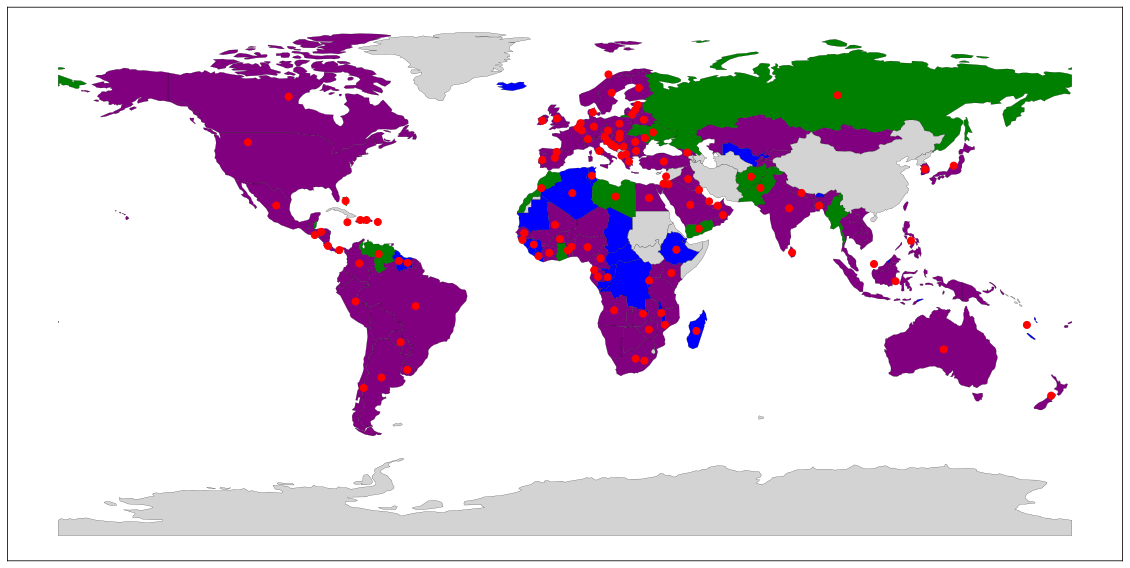

In [8]:
#| label: fig-inc
#| fig-cap: Included countries and mobility availability. Countries coloured according to mobility availability. Neither source available, grey; Google mobility only available, green; Facebook mobility only available, blue; both sources available, purple. Red markers indicate included in analysis.
world = get_world_shp()
world["geometry"] = world.simplify(tolerance=0.1)
add_mob_avail_to_world(world, g_avail, fb_avail)
world["included"] = world["ISO_A3"].isin(included)
plot_inclusion(world);

In [9]:
#| label: tbl-inc
#| tbl-cap: Reasons for country inclusion and exclusion.
summary.index = summary.index.map(lambda iso3: pycountry.countries.lookup(iso3).name)
display(Markdown(summary.sort_index().to_markdown()))

|                                       | Google available   | FB available   | No death data   | No case data   | Negative values present   | Outlier values present   | Absent or repeat values   | Incl-uded   |
|:--------------------------------------|:-------------------|:---------------|:----------------|:---------------|:--------------------------|:-------------------------|:--------------------------|:------------|
| Afghanistan                           | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Albania                               | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Algeria                               | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| American Samoa                        | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Angola                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Antigua and Barbuda                   | Yes                | No             | No              | No             | No                        | No                       | Yes                       | No          |
| Argentina                             | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Aruba                                 | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Australia                             | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Austria                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Bahamas                               | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Bahrain                               | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Bangladesh                            | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Barbados                              | Yes                | No             | No              | No             | No                        | No                       | Yes                       | No          |
| Belarus                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Belgium                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Belize                                | Yes                | No             | No              | No             | No                        | No                       | Yes                       | No          |
| Benin                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Bhutan                                | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Bolivia, Plurinational State of       | Yes                | Yes            | No              | No             | No                        | Yes                      | No                        | No          |
| Bosnia and Herzegovina                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Botswana                              | Yes                | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Brazil                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Brunei Darussalam                     | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Bulgaria                              | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Burkina Faso                          | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Burundi                               | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Cabo Verde                            | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Cambodia                              | Yes                | Yes            | No              | No             | No                        | Yes                      | Yes                       | No          |
| Cameroon                              | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Canada                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Central African Republic              | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Chad                                  | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Chile                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Colombia                              | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Congo                                 | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Congo, The Democratic Republic of the | No                 | Yes            | No              | No             | No                        | Yes                      | No                        | No          |
| Costa Rica                            | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Croatia                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Czechia                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Côte d'Ivoire                         | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Denmark                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Djibouti                              | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Dominica                              | No                 | Yes            | Yes             | No             | No                        | No                       | Yes                       | No          |
| Dominican Republic                    | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Ecuador                               | Yes                | Yes            | No              | No             | Yes                       | Yes                      | No                        | No          |
| Egypt                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| El Salvador                           | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Equatorial Guinea                     | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Estonia                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Ethiopia                              | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Faroe Islands                         | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Fiji                                  | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Finland                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| France                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| French Guiana                         | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Gabon                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Gambia                                | No                 | Yes            | No              | No             | No                        | Yes                      | Yes                       | No          |
| Georgia                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Germany                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Ghana                                 | Yes                | No             | No              | No             | No                        | Yes                      | Yes                       | No          |
| Greece                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Guadeloupe                            | No                 | Yes            | No              | No             | Yes                       | No                       | No                        | No          |
| Guatemala                             | Yes                | Yes            | No              | No             | Yes                       | No                       | No                        | No          |
| Guinea                                | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Guinea-Bissau                         | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Guyana                                | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Haiti                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Honduras                              | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Hong Kong                             | Yes                | No             | Yes             | Yes            | No                        | No                       | No                        | No          |
| Hungary                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Iceland                               | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| India                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Indonesia                             | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Iraq                                  | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Ireland                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Israel                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Italy                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Jamaica                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Japan                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Jordan                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Kazakhstan                            | Yes                | Yes            | No              | No             | No                        | Yes                      | No                        | No          |
| Kenya                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Korea, Republic of                    | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Kuwait                                | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Kyrgyzstan                            | Yes                | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Lao People's Democratic Republic      | Yes                | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Latvia                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Lebanon                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Lesotho                               | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Liberia                               | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Libya                                 | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Liechtenstein                         | Yes                | No             | No              | No             | No                        | No                       | Yes                       | No          |
| Lithuania                             | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Luxembourg                            | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Madagascar                            | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Malawi                                | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Malaysia                              | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Mali                                  | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Malta                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Martinique                            | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Mauritania                            | No                 | Yes            | No              | No             | No                        | Yes                      | No                        | No          |
| Mauritius                             | Yes                | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Mexico                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Moldova, Republic of                  | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Mongolia                              | Yes                | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Morocco                               | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Mozambique                            | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Myanmar                               | Yes                | No             | No              | No             | No                        | No                       | Yes                       | No          |
| Namibia                               | Yes                | Yes            | Yes             | Yes            | No                        | No                       | No                        | No          |
| Nepal                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Netherlands                           | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| New Caledonia                         | No                 | Yes            | No              | No             | No                        | Yes                      | No                        | No          |
| New Zealand                           | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Nicaragua                             | Yes                | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Niger                                 | Yes                | Yes            | No              | No             | No                        | Yes                      | Yes                       | No          |
| Nigeria                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| North Macedonia                       | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Norway                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Oman                                  | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Pakistan                              | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Panama                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Papua New Guinea                      | Yes                | Yes            | No              | No             | No                        | Yes                      | No                        | No          |
| Paraguay                              | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Peru                                  | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Philippines                           | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Poland                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Portugal                              | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Puerto Rico                           | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Qatar                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Romania                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Russian Federation                    | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Rwanda                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Réunion                               | Yes                | Yes            | No              | No             | Yes                       | No                       | No                        | No          |
| Samoa                                 | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Sao Tome and Principe                 | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Saudi Arabia                          | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Senegal                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Serbia                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Sierra Leone                          | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Singapore                             | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Slovakia                              | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Slovenia                              | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| South Africa                          | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Spain                                 | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Sri Lanka                             | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Suriname                              | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Sweden                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Switzerland                           | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Taiwan, Province of China             | Yes                | Yes            | Yes             | Yes            | No                        | No                       | No                        | No          |
| Tajikistan                            | Yes                | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Tanzania, United Republic of          | Yes                | Yes            | No              | No             | No                        | Yes                      | Yes                       | No          |
| Thailand                              | Yes                | Yes            | No              | No             | Yes                       | No                       | No                        | No          |
| Timor-Leste                           | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Togo                                  | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Trinidad and Tobago                   | Yes                | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Tunisia                               | No                 | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Türkiye                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Uganda                                | Yes                | Yes            | No              | No             | No                        | Yes                      | Yes                       | No          |
| Ukraine                               | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| United Arab Emirates                  | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| United Kingdom                        | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| United States                         | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Uruguay                               | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Uzbekistan                            | No                 | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Vanuatu                               | No                 | Yes            | No              | No             | No                        | Yes                      | Yes                       | No          |
| Venezuela, Bolivarian Republic of     | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Viet Nam                              | Yes                | Yes            | No              | No             | No                        | No                       | Yes                       | No          |
| Virgin Islands, U.S.                  | No                 | Yes            | No              | No             | Yes                       | No                       | No                        | No          |
| Yemen                                 | Yes                | No             | No              | No             | No                        | No                       | No                        | Yes         |
| Zambia                                | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |
| Zimbabwe                              | Yes                | Yes            | No              | No             | No                        | No                       | No                        | Yes         |

\newpage
# Parameter choices and supporting evidence

In [10]:
loaded_priors = yml.safe_load(open(BASE_PATH / "data/evidence/priors.yml", "r"))
duration_params = loaded_priors["durations"]

## Time period parameters

In [11]:
col_widths = '{tbl-colwidths="[12, 7, 7, 74]"}'
durations_df = get_table_df_from_priors_dict(loaded_priors["durations"])
keep_cols = [c for c in durations_df if c != "Short_name"]
dur_table = durations_df[keep_cols]
caption = ": Parameters and supporting evidence to time period priors. "
Markdown(dur_table.to_markdown() + "\n" + caption + col_widths)

|                                                        |   Mean |   SD | Evidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
|:-------------------------------------------------------|-------:|-----:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Generation time mean (days)                            |   4.25 | 0.75 | We used analyses of case-contact transmission pairs from multiple contexts for SARS-CoV-2 as the main evidence to quantify the generation time distribution. \newline\newline Case-contact data from the origin of the pandemic in Wuhan estimated a mean generation time of around seven days prior to the scaling up of population-wide public health and social measures, such as expanded contact tracing and movement restrictions. This led to a notable contraction of the mean generation time to around four to five days after these interventions had been implemented.[@chen2022] This study also found marked differences between the generation time and serial interval, due to changes in the epidemic that were sufficiently rapid to result in differences in the incubation period between infectors and infectees. Values of around four to five days are also consistent with an analysis from early 2020 from Tianjin, China and Singapore, in which estimates of the serial interval estimates were close to that of the generation time[@ganyani2020]. \newline\newline Estimates of the serial interval from household clusters in Germany[@anderheiden2022] also found that values of four to five days were appropriate for wild-type, Alpha and Delta SARS-CoV-2 variants, although these appeared less applicable to Omicron. Estimates from close contacts in Spain[@delaguilamejia2022] similarly placed the serial interval of the Delta variant at around five days, while an early study from China similarly placed the mean serial interval for wild-type SARS-CoV-2 at around four to five days.[@he2020] \newline\newline A systematic review and meta-analysis of this topic found more studies estimating the serial interval than the generation time, with mean estimates for the serial interval of 4.82 days, 3.59 days and 3.47 days reported for wild-type, Alpha and Delta respectively.[@xu2023] Estimates for the generation time from this review were similar, but with wider confidence limits. A rapid review of serial intervals from a different research group reported similar findings.[@madewell2023] There was notable variation in these findings, with results of individual studies from these systematic reviews estimating mean values for the serial interval of less than three days to more than six days. |
| Generation time mean (days), Oceania                   |   3    | 0.75 | An analysis from China estimated that the generation time fell from 5.2 days to 2.2 days over the course of an Omicron outbreak in Hangzhou in 2022.[@xin2023] The systematic review of generation times by variant cited above estimated a mean generation time of 2.96 days (95% confidence interval 2.54 to 3.38 days).[@xu2023] A rapid review and meta-analysis of generation times by variant found a pooled estimate of 3.3 days for Omicron.[@madewell2023] \newline\newline As such, we chose a generation interval mean for the Singapore and Oceania analyses of three days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| Generation time standard deviation (days)              |   2    | 0.4  | For the standard deviation of the generation interval, we generally used the same sources of evidence as for the mean. However, the systematic reviews and many of the individual studies presented their results as point estimates with confidence intervals, rather than reporting the standard deviations of the data of the individual studies, making these results less applicable to this parameter. \newline\newline In studies that reported standard deviations, estimates included two to four days for early Wuhan [@chen2022] and 1.5 to 2.5 days from Tianjin and Singapore.[@ganyani2020]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| Infection to reporting mean (days)                     |   8    | 0.5  | This quantity is a composite of the incubation period and the delay from symptom onset to diagnosis, although the latter of these quantities is not widely reported. The review cited above in estimating the generation time found estimates of the incubation period of 6.5, 4.92 and 4.63 days for the wild-type, Alpha and Delta variants respectively.[@xu2023] A meta-analysis of early cases reported a mean incubation period of 5.68 days[@khalili2020], while an analysis of early cases in China found a mean incubation period of 5.2 days.[@li2020] As such, although the incubation period was not an explicit model parameter, we considered five days to be a plausible central estimate when considering parameters required for the convolutions applied in our analysis, including this one. \newline\newline Regarding the delay from symptom onset to case notification, an analysis from Australia found that this quantity was often in the range of one to seven days after the first wave of cases in early 2020 had declined.[@golding2023] This is consistent with a survey from the USA that reported a median of three days unwell before testing.[@tenforde2020] A study of case notifications in New York City found a mean delay from testing to case notification of 3.3 days.[@harris2022] WHO reported that the median time from symptom onset to laboratory confirmation had decreased to three days by early February 2020.[@who2020] Our previous analysis of the Australian epidemic found that our prior estimate of three to five days was not markedly influenced through calibration.[@trauer2025] \newline\newline Studies of the time from exposure to diagnosis include a study from South Korea which found an average of 3.7 days,[@lee2022] although this very short interval likely reflects proactive testing for these quarantined close contacts. An analysis from the USA estimated that infections could peak anywhere from six to 41 days before peaks in case notification.[@lobay2025] \newline\newline Overall, we considered that a mean time from infection to case notification of eight days would be consistent with a five-day incubation period followed by a three-day average delay from symptom onset to case notification.                                                                               |
| Infection to reporting standard deviation (days)       |   3    | 0.5  | Although person-to-person variation in the incubation period was not typically quantified in systematic reviews,[@xu2023] individual studies reported standard deviations of around three days[@li2020]. \newline\newline The survey from the USA reported an interquartile range for the time to testing from feeling unwell that spanned five days.[@tenforde2020] Most delays in the study from New York fell in the range from one to five days,[@harris2022] while the WHO report cited above described an interquartile range that spanned six days.[@who2020] \newline\newline Given this background, we considered that a standard deviation for the time from infection to case notification of three days was plausible, and set the standard deviation for the prior of this parameter distribution to 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| Infection to death mean (days)                         |  22    | 5    | The meta-analysis of early studies from China cited above[@khalili2020] estimated the mean duration from symptom onset to death to be 15.93 days. A study leveraging individual-level data from Hubei, China in combination with early cases outside of China (not included in the meta-analysis) found a mean time from symptom onset to death of 17.8 days.[@verity2020] This was similar to a report from a single centre study from Wuhan (Hubei, China) during a time of major health system strain, which found a median time to death of 15 days,[@zhang2020] and another single centre study of early cases from Wuhan which reported a median time to death of 16 days.[@chen2020] A cohort study from a north-eastern state of Brazil found a median 19 days from symptom onset to death.[@sousa2020] An analysis of deaths from Victoria, Australia over the course of 2020 found a mean time to death of 18.1 days.[@marschner2021] \newline\newline We therefore considered 17 days to be a reasonable estimate for the time from symptom onset to death, which we increased by five days to account for the time from infection to symptom onset.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| Infection to death standard deviation (days)           |   3    | 0.5  | The first single centre study from Wuhan cited above reported an interquartile range which spanned nine days,[@zhang2020] while the second reported a span of eight days.[@chen2020] The interquartile range from the study in north-eastern Brazil spanned 11 days.[@sousa2020] \newline\newline We considered that the standard deviation for the infection to death prior would be broadly of the order of one quarter the ranges reported by these individual studies, although inflated slightly to account for the uncertainty in the incubation period. We therefore set this parameter to three days, with a standard deviation to the distribution of 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| Infection to hospitalisation mean (days)               |  10    | 3    | One of the earliest studies of cases from China found a median time from onset of symptoms to hospital admission of seven days,[@huang2020] while a single centre study from Wuhan reported a median time from symptom onset to hospital admission of ten days.[@chen2020] A cohort of adult patients admitted to an Italian hospital found a mean time from onset of symptoms to hospital admission of 3.6 days,[@gentilotti2021] while a study from Belgium reported the mean duration from symptom onset to hospitalisation to be 5.6 days.[@faes2020] The final report of the ISARIC collaboration reported a mean of 5.4 days from symptom onset to admission.[@isaric2023] \newline\newline Given this evidence, we chose a mean value for the time from infection to death prior of five days. As for the time from infection to hospital admission parameter, we inflated this by five days to allow for the incubation period.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| Infection to hospitalisation standard deviation (days) |   2    | 0.5  | The early study of cases from China reported an interquartile range that spanned four days,[@huang2020] while the single centre study from Wuhan reported an interquartile range spanning six days.[@chen2020] The Italian cohort of hospital admissions reported the standard deviation of the time from symptom onset to hospitalisation to be 3.2 days.[@gentilotti2021] The study from Belgium cited above found considerable variation in the time to admission, with the interquartile range spanning six days.[@faes2020] \newline\newline As with previous parameters, we selected a prior standard deviation of slightly more than one quarter of the spread in the data in the constituent studies. We therefore chose a central estimate for this standard deviation parameter of two days, with a standard deviation to this distribution of 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| Hospital stay duration mean (days)                     |  10    | 3    | An analysis of surveillance data from Belgium reported a mean length of hospital stay of 11.0 days,[@faes2020] while a multi-centre study from the USA reported a mean length of hospital stay of 14.7 days.[@finelli2021] The single centre study from Wuhan cited above reported a median time from hospital admission to discharge of 16 days, with a median time from admission to death of five days.[@chen2020] \newline\newline A systematic review of hospital admission durations found a median length of stay of 14 days in China, but only five days outside of China.[@rees2020], while a scoping review of infectious durations reported that the mean time from symptom onset to hospital discharge or death was 18.1 days.[@byrne2020] Another systematic review undertaken later in the pandemic period found similar durations, with a mean length of stay of 15.35 days.[@alimohamadi2022] \newline\newline The final report of the ISARIC collaboration reported a mean 9.7 days (median seven days) length of hospital stay.[@isaric2023]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| Hospital stay duration standard deviation (days)       |   2.5  | 0.5  | The analysis from Belgium cited above reported an interquartile range that spanned ten days,[@faes2020] while the multi-centre study from the USA reported a standard deviation of 13.7 days.[@finelli2021] \newline\newline The interquartile range reported in the first systematic review above[@rees2020] was ten to 19 days, while the individual-level standard deviation identified in the later systematic review above[@alimohamadi2022] was 7.92 days. \newline\newline As such, we implemented a standard deviation for hospital admission duration of 2.5 days, with a standard deviation to this parameter prior of 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| Infection to ICU admission mean (days)                 |  12    | 3    | A single centre study from Wuhan found a median duration from symptom onset to ICU admission of 9.5 days,[@yang2020] while an early study of cases from China found a median time from onset of symptoms to ICU admission of 10.5 days.[@huang2020] A study from two hospitals in China reported a median time from illness onset to ICU admission of 12.0 days.[@zhou2020] The study from north-eastern Brazil reported a median six days from symptom onset to ICU admission.[@sousa2020] \newline\newline The final report from the ISARIC collaboration estimated a mean time from symptom onset to hospital admission of 5.4 days and a mean time from hospital admission to ICU admission of 1.8 days.[@isaric2023] \newline\newline Given this evidence, we implemented a mean for our prior distribution of time from infection to ICU admission of seven days to allow for a five day incubation period.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| Infection to ICU admission standard deviation (days)   |   2.5  | 0.5  | The single centre study from Wuhan cited above reported an interquartile range around the time from admission to discharge that spanned five days, while the time to death spanned six days.[@chen2020] The study of early cases from China reported an interquartile range that spanned nine days,[@huang2020] while the study from two hospitals in China reported an interquartile range that spanned 7.0 days.[@zhou2020] The second single centre study from Wuhan reported an interquartile range from the onset of symptoms to ICU admission that spanned 5.5 days.[@yang2020] The analysis from Belgium cited above reported an interquartile range for ICU admission that spanned 13 days.[@faes2020] The multi-centre study from the USA reported a standard deviation for the ICU admission duration of 8.3 days.[@finelli2021] The study in north-eastern Brazil reported an interquartile range around the time to ICU admission that spanned 6.5 days.[@sousa2020] \newline\newline We therefore implemented a standard deviation for our time from infection to ICU admission parameter of 2.5 days, with a standard deviation to this distribution of 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| ICU stay duration mean (days)                          |  10    | 3    | The analysis from Belgium cited above reported a mean length of ICU stay of 12.2 days,[@faes2020] while the multi-centre study from the USA cited above reported a mean ICU admission duration of 8.3 days.[@finelli2021] The study from multiple regions of Brazil indicated the median length of ICU stay was five days.[@desouza2020] \newline\newline The systematic review introduced above[@rees2020] reported a median ICU length of stay outside of China of seven days. The final report from ISARIC gave a mean duration of stay in ICU of 10.3 days.[@isaric2023] \newline\newline We therefore chose a mean for the prior distribution of the duration of ICU stay of ten days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| ICU stay duration standard deviation (days)            |   2.5  | 0.5  | The study from multiple regions of Brazil reported an interquartile range that spanned eight days,[@desouza2020] while the final ISARIC report provided a standard deviation for ICU duration of 10.4 days.[@isaric2023] \newline\newline We therefore chose a standard deviation of 2.5 days for this prior distribution and assigned a standard deviation for the spread of this parameter of 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
: Parameters and supporting evidence to time period priors. {tbl-colwidths="[12, 7, 7, 74]"}

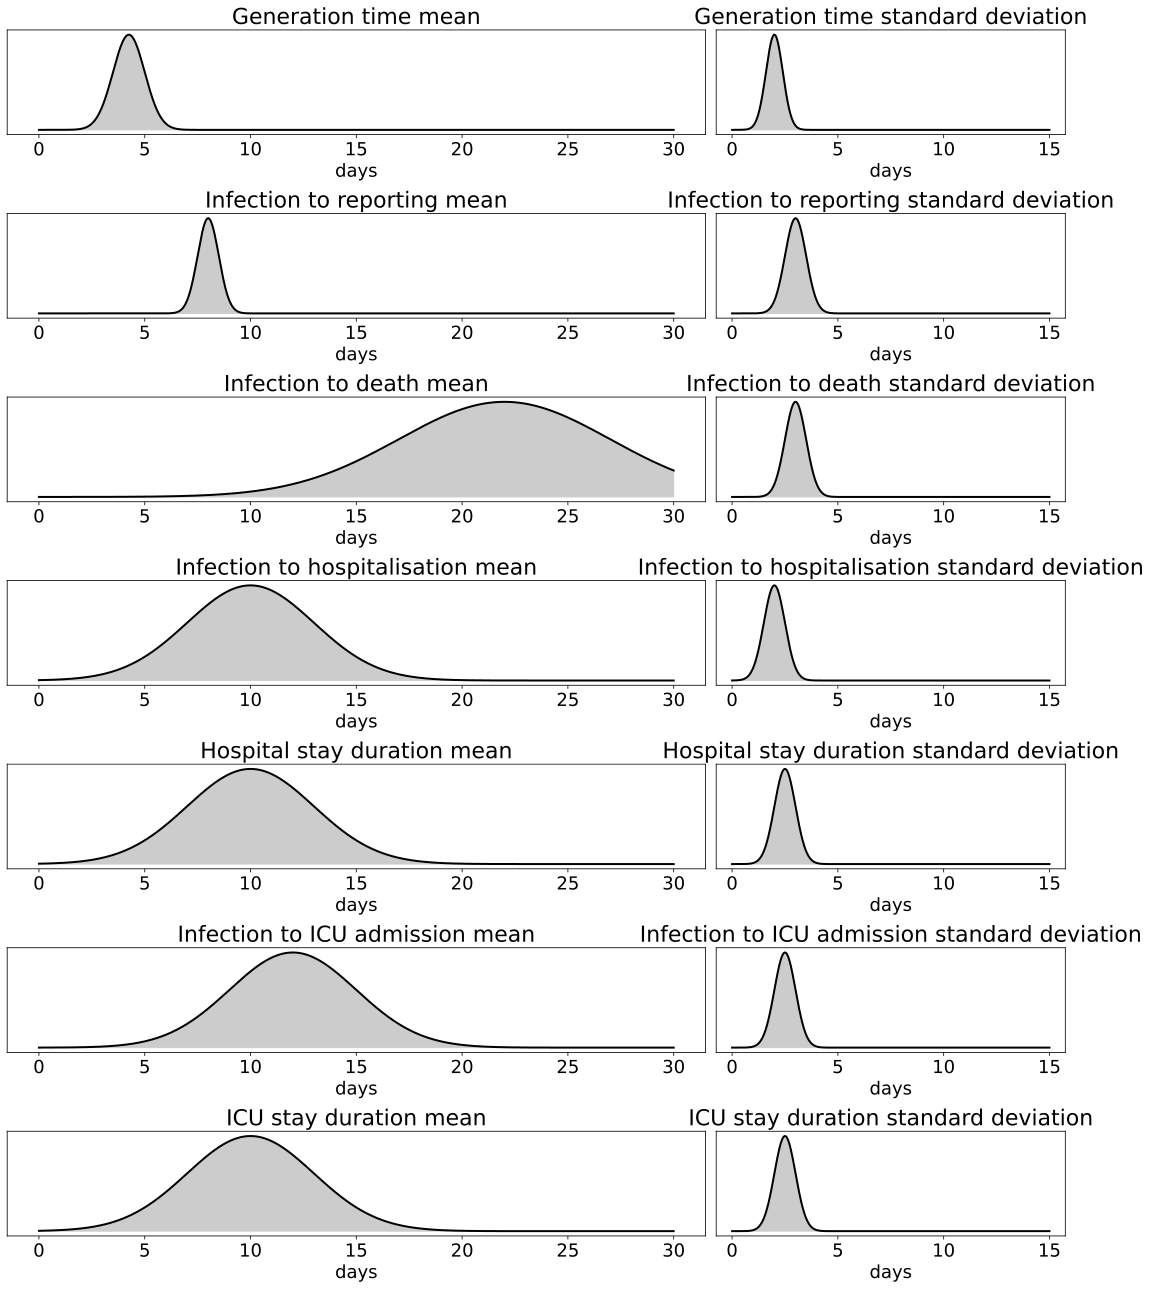

In [12]:
#| fig-cap: Duration-related parameter prior distributions.
plot_duration_params(duration_params)

{{< pagebreak >}}
## Proportion parameters

In [13]:
betas_df = get_table_df_from_priors_dict(loaded_priors["beta"])
caption = ": Parameters and supporting evidence to beta-distributed priors. "
Markdown(betas_df.to_markdown() + "\n" + caption + col_widths)

|                                      |   Mean |    SD | Evidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
|:-------------------------------------|-------:|------:|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Case detection proportion            |  0.4   | 0.1   | An analysis from France in early to mid-2020 of the proportion of cases detected estimated that case ascertainment increased from 7% to 38% (95% confidence interval 35 to 44%) over time.[@pullano2020] A study of multiple countries found that case detection was highly dependent on the country considered, but reached 20 to 60% in several European countries by the middle of 2020.[@russell2020] Estimates from the UK Health Security Agency placed the proportion of cases detected over time at around 30 to 60% from the latter half of 2020.[@ukhsa2024] These estimates are consistent with our previous estimate that one in two to one in six cases were detected from the early stages of Australia's Omicron outbreak.[@trauer2025] An analysis from Africa estimated generally lower case ascertainment proportions, which also varied significantly by country.[@impouma2021] \newline\newline Given the difficulty in determining an appropriate prior for this parameter and the likelihood that the quantity is highly setting-dependent, we selected a broad prior distribution for this parameter. |
| Cross immunity                       |  0.5   | 0.1   | A pre-print describing a large dataset from the USA in 2020 found an 87% lower rate of reinfection compared to primary infection over a median five months of follow-up.[@reynolds2022] \newline\newline A systematic review and meta-analysis found that protection against re-infection declined with time and varied with the variant considered, but was estimated at 78.6% after 40 weeks from infection (95% uncertainty interval 49.8 to 93.6%).[@covidforecasting2023] Another systematic review and meta-analysis of the same topic found 65% protection (credible interval 53 to 74%) overall, with the past infecting variant and time from infection appearing to modify the extent of protection.[@hu2024] A systematic review and meta-regression of reinfections with Omicron variants found that protection from previous infections waned to lower levels (25%) by 12 months from infection.[@bobrovitz2023]                                                                                                                                                                                                |
| Infection hospitalisation proportion |  0.03  | 0.006 | This quantity was estimated to be 3.39% (credible interval 2.79 to 3.97%) from officially reported data in England prior to the marked declines that occurred as population-wide vaccination was rolled out.[@ward2024] An analysis from Indiana, USA estimated a value of 2.1% overall (credible interval 1.6 to 3.0%), with substantial variation by demographic factors, particularly age.[@menachemi2021] A study from the USA estimated that one in three adults aged 70 years and above who were infected were hospitalised, while one in 21.6 infections in those aged 18 to 49 years resulted in hospitalisation.[@deng2025]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| Infection fatality proportion        |  0.008 | 0.001 | An analysis that integrated serosurveillance with age-specific death rates from 45 countries estimated an infection fatality rate of 0.79% (credible interval 0.68 to 0.92%) for the reference population distribution of France.[@odriscoll2021] Other groups have found similar estimates using a combination of modelling and serosurvey results, including an overall IFR estimated at 0.49 to 2.53%.[@brazeau2022] The analysis from England of the hospitalisation risk estimated a peak infection fatality risk of 0.97% in January 2021, which fell to 0.06% by April 2022.[@ward2024] \newline\newline We selected a prior distribution with a central estimate of 0.8%. Our prior estimate is relatively broadly distributed and so should be applicable to a range of higher income settings.                                                                                                                                                                                                                                                                                                                     |
| ICU admission proportion             |  0.01  | 0.001 | The analysis from Indiana cited above found an infection ICU admission risk of 0.51% (credible interval 0.38% to 0.70%).[@menachemi2021] An analysis from Chile found a risk of ICU admission given infection of 0.33, 1.18, 3.59 and 7.18% for the age groups under 40, 40 to 49, 50 to 59 and 60 to 69 respectively.[@saure2023] A systematic review and meta-analysis from early in the pandemic period found that 32% of hospital admissions resulted in ICU admission.[@abate2020] \newline\newline We therefore chose a central estimate for this parameter of 1%.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
: Parameters and supporting evidence to beta-distributed priors. {tbl-colwidths="[12, 7, 7, 74]"}

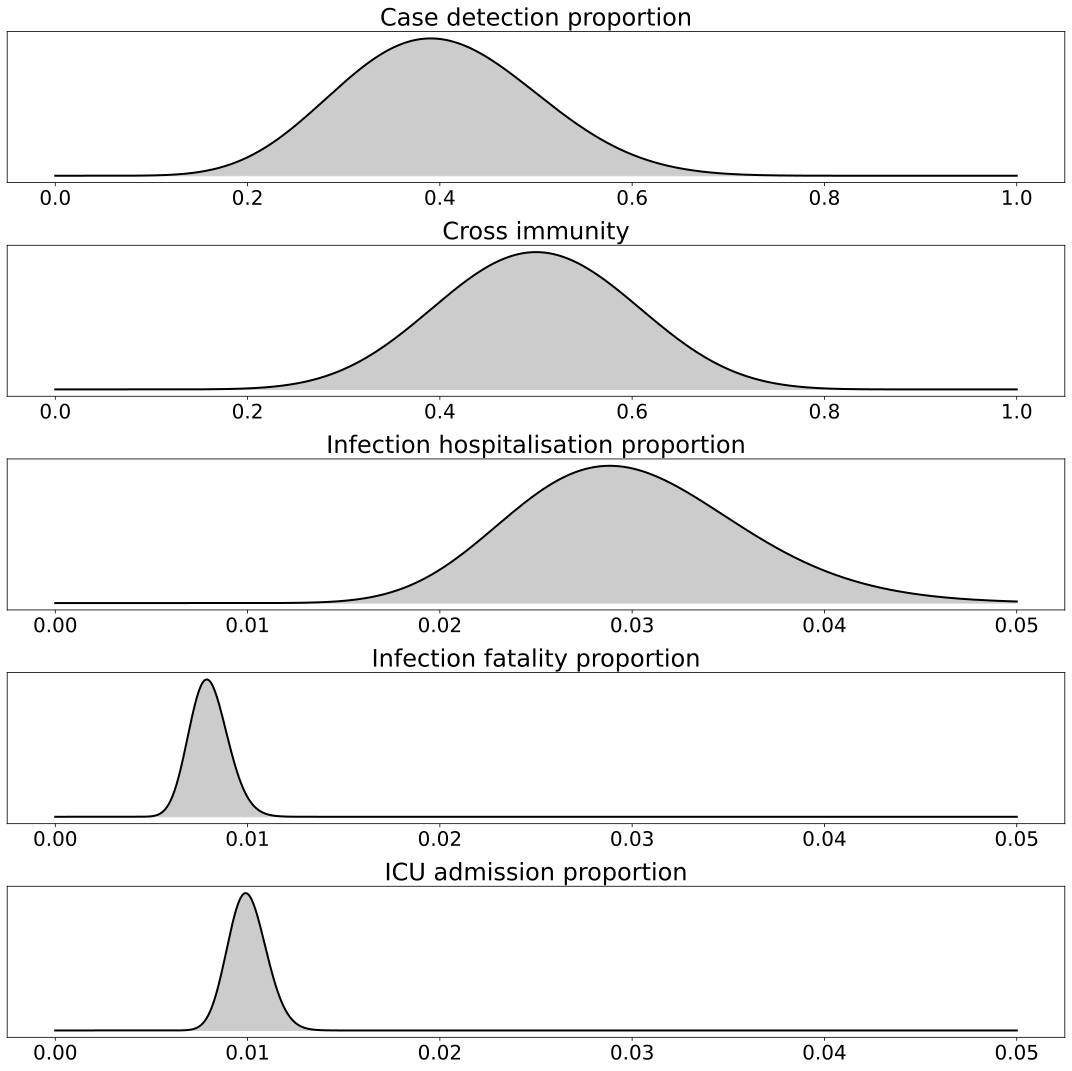

In [14]:
#| fig-cap: Proportion parameter prior distributions. Note horizontal axis range differs between upper two panels and lower three panels.
plot_beta_priors(loaded_priors["beta"])

In [15]:
fixed_params = loaded_priors["fixed"]
params_df = pd.DataFrame.from_dict(fixed_params).T
params_df = params_df.set_index("param_name")
params_df.columns = params_df.columns.str.capitalize()
params_df.index.name = None
caption = "\n: Fixed parameters and supporting evidence. "

{{< pagebreak >}}
## Fixed parameters

In [16]:
Markdown(params_df.to_markdown() + caption + '{tbl-colwidths="[12, 7, 81]"}')

|                                                |   Value | Evidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
|:-----------------------------------------------|--------:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Vaccination protection against hospitalisation |    0.5  | The first estimate of the efficacy of BNT162b2 mRNA vaccine that was widely used in Australia, found a total efficacy of 95% protection against COVID-19.[@polack2020] \newline\newline However, protection against infection will be captured by scaling the modelled transmission parameters, including the variable process. As such, the evidence needed for this quantity is the real-world reduction in the risk of hospitalisation and death given infection. \newline\newline Estimates of the real-world protection of vaccination against SARS-CoV-2 infections found 85% protection (95% confidence interval 81 to 89%) against infection, but higher protection against severe outcomes, including hospitalisation (93%), ICU admission (98%) and death (95%).[@liu2021] \newline\newline As such, we estimated the reduction in hospitalisation given infection to be 50%. |
| Vaccination protection against death           |    0.67 | Using the same evidence as for the protection against hospitalisation, we estimated this parameter at 67%.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
: Fixed parameters and supporting evidence. {tbl-colwidths="[12, 7, 81]"}

{{< pagebreak >}}
## Relative infectiousness parameter

In [17]:
Markdown(loaded_priors["other"]["relinfect"]["evidence"])

For the relative infectiousness of the Alpha variant of SARS-CoV-2 compared to preceding strains, a study of household contacts in Japan found a transmissibility of 1.9 to 2.3 times,[@tanaka2021] while another such study from Norway round a secondary attack rate that was 1.81-fold higher.[@julin2021] Another study from Norway employing data obtained from contact tracing round an increase in the secondary attack rate of 60% in households, but 24% across all close contacts.[@lindstrom2022] \newline\newline Regarding the relative infectiousness of the Delta variant compared to Alpha, the adjusted odds ratio for transmission was found to be 1.70 (95% credible interval 1.48 to 1.95) in a national case-control study from England.[@allen2022] Contact tracing data from Spain found a relative risk of transmission of 1.32 (95% confidence interval 1.13 to 1.53) for Delta versus Alpha.[@trobajo2022]

{{< pagebreak >}}

# References